# Phase 3: Exploratory Data Analysis (EDA)

**Traceability**
- Issue ID: #3 Exploratory Data Analysis
- Upstream dependency: `02_data_cleaning.ipynb` (cleaned, noise-controlled data)

**External References**:
- [Carl Kirstein - Predictive Maintenance](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) (Correlation Analysis, Sensor Naming)
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (Trend Visualization)

## 1. Objective
Generate statistically grounded evidence guiding feature creation and model choices.

## 2. Inputs & Dependencies
- `data/processed/train_cleaned.csv` and `valid_cleaned.csv` from notebook 02.
- Cleaned data with 14 remaining sensors (constant/near-constant sensors already removed).

## 3. Methodology
1. Load cleaned data and compute RUL targets.
2. Analyze engine lifetime distribution.
3. Profile univariate sensor distributions.
4. Plot sensor degradation trends vs RUL.
5. Compute correlation structures and redundancy diagnostics.
6. Validate trends with statistical tests (Spearman correlation significance).
7. Perform PCA variance analysis.
8. Produce decision log for feature engineering.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# ── Plotting Config ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
COLORS = ['#1F4E79', '#2E75B6', '#70AD47', '#FF7043', '#AB47BC']

# ── Global Config ────────────────────────────────────────────────────────
DATA_DIR = Path('../data')
PROCESSED_DIR = Path('../data/processed')

# ── Load Processed Data from Notebook 02 ────────────────────────────────
print("⏳ Loading cleaned datasets from notebook 02...")
df_train = pd.read_csv(PROCESSED_DIR / 'train_cleaned.csv')
df_valid = pd.read_csv(PROCESSED_DIR / 'valid_cleaned.csv')

# Identify column groups
SENSOR_COLS = [c for c in df_train.columns if c.startswith('s_')]
sensor_cols = SENSOR_COLS.copy()
INDEX_COLS = ['unit_number', 'time_cycles']
SETTING_COLS = [c for c in df_train.columns if c.startswith('setting_')]

print(f"✅ Loaded. Train: {df_train.shape}, Valid: {df_valid.shape}")
print(f"   Sensors: {len(SENSOR_COLS)}, Settings: {len(SETTING_COLS)}")

# ── Compute RUL (needed for all EDA analyses) ──────────────────────────
def add_RUL(df):
    """Add RUL column using max-cycle method."""
    max_c = df.groupby('unit_number')['time_cycles'].max().to_frame('max_c')
    merged = df.merge(max_c, left_on='unit_number', right_index=True)
    merged['RUL'] = merged['max_c'] - merged['time_cycles']
    return merged.drop('max_c', axis=1)

df_train = add_RUL(df_train)
print(f"   RUL range: [{df_train['RUL'].min()}, {df_train['RUL'].max()}]")

⏳ Loading cleaned datasets from notebook 02...
✅ Loaded. Train: (20631, 20), Valid: (13096, 20)
   Sensors: 14, Settings: 3
   RUL range: [0.0, 361.0]


In [2]:
df_train.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,1.0,1.0,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392.0,39.06,23.4190,191.0
1,1.0,2.0,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392.0,39.00,23.4236,190.0
2,1.0,3.0,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390.0,38.95,23.3442,189.0
3,1.0,4.0,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.80,2388.08,8133.83,8.3685,392.0,38.88,23.3739,188.0
4,1.0,5.0,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393.0,38.90,23.4044,187.0


### 3.1 Engine Lifetime Distribution
Analyze how long engines typically last to understand the degradation timeline and inform RUL clipping decisions.

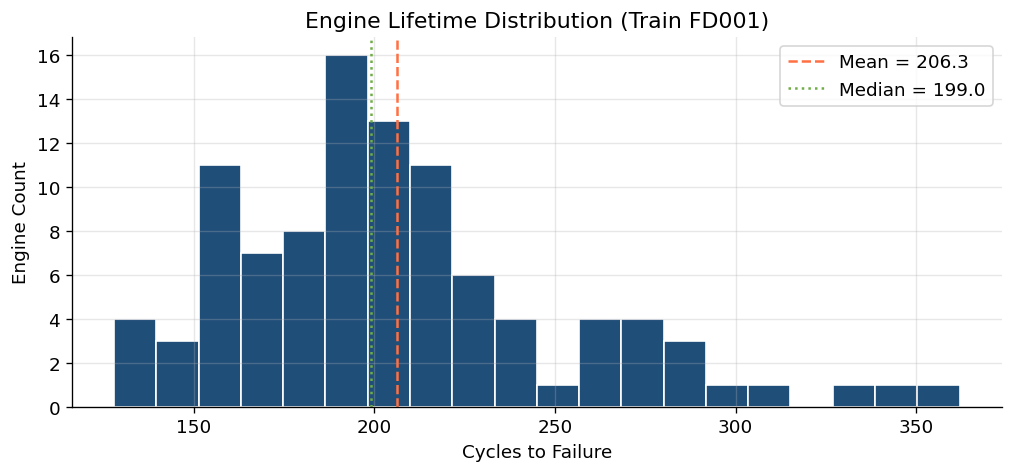

--- Engine Lifetime Stats ---
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_cycles, dtype: float64


In [3]:
def engine_lifetime_analysis(df):
    """Plot distribution of engine lifetimes."""
    max_cycles = df.groupby('unit_number')['time_cycles'].max()
    
    plt.figure(figsize=(10, 4))
    plt.hist(max_cycles, bins=20, color=COLORS[0], edgecolor='white')
    plt.axvline(max_cycles.mean(), color=COLORS[3], linestyle='--', label=f'Mean = {max_cycles.mean():.1f}')
    plt.axvline(max_cycles.median(), color=COLORS[2], linestyle=':', label=f'Median = {max_cycles.median():.1f}')
    plt.title('Engine Lifetime Distribution (Train FD001)')
    plt.xlabel('Cycles to Failure')
    plt.ylabel('Engine Count')
    plt.legend()
    plt.show()
    
    return max_cycles.describe()

lifetime_stats = engine_lifetime_analysis(df_train)
print("--- Engine Lifetime Stats ---")
print(lifetime_stats)

### Graph Analysis: Engine Lifetime Distribution

- The distribution is right-skewed: most engines fail around ~170–230 cycles, but a smaller group survives much longer (up to ~360 cycles).
- Mean lifetime (**206.3**) is higher than median (**199.0**), confirming the right tail from long-lived engines.
- This spread indicates meaningful unit-to-unit heterogeneity; a single global degradation pace assumption is likely too simplistic.
- The dense central region suggests many engines follow a common lifecycle, while tail engines may represent different operating conditions or initial health states.
- Modeling implication: avoid hard stage cutoffs based only on fixed cycle numbers; prefer RUL-relative features and per-unit temporal dynamics.
- Validation implication: preserve distribution shape across splits so the long-lifetime tail is represented in train/validation sets.

#### Suggested Actions
1. **Use piecewise-linear (clipped) RUL target** — clip RUL at 125 cycles so the model focuses on the degradation region rather than wasting capacity on the flat healthy plateau.
2. **Keep per-unit grouping** in all temporal feature engineering (`groupby('unit_number')`) to respect engine boundaries and heterogeneity.
3. **Do NOT filter short- or long-lived engines** — the tail engines carry valid signal and removing them would bias the model.
4. **Consider cycle-normalized features** (e.g., `time_cycles / max_cycle_for_unit`) as an auxiliary input to help the model learn relative position within each engine's lifecycle.

### 3.2 Univariate Sensor Distribution Profiling
Examine individual sensor distributions to assess normality, skewness, and range characteristics. This informs scaling and transformation decisions for feature engineering.

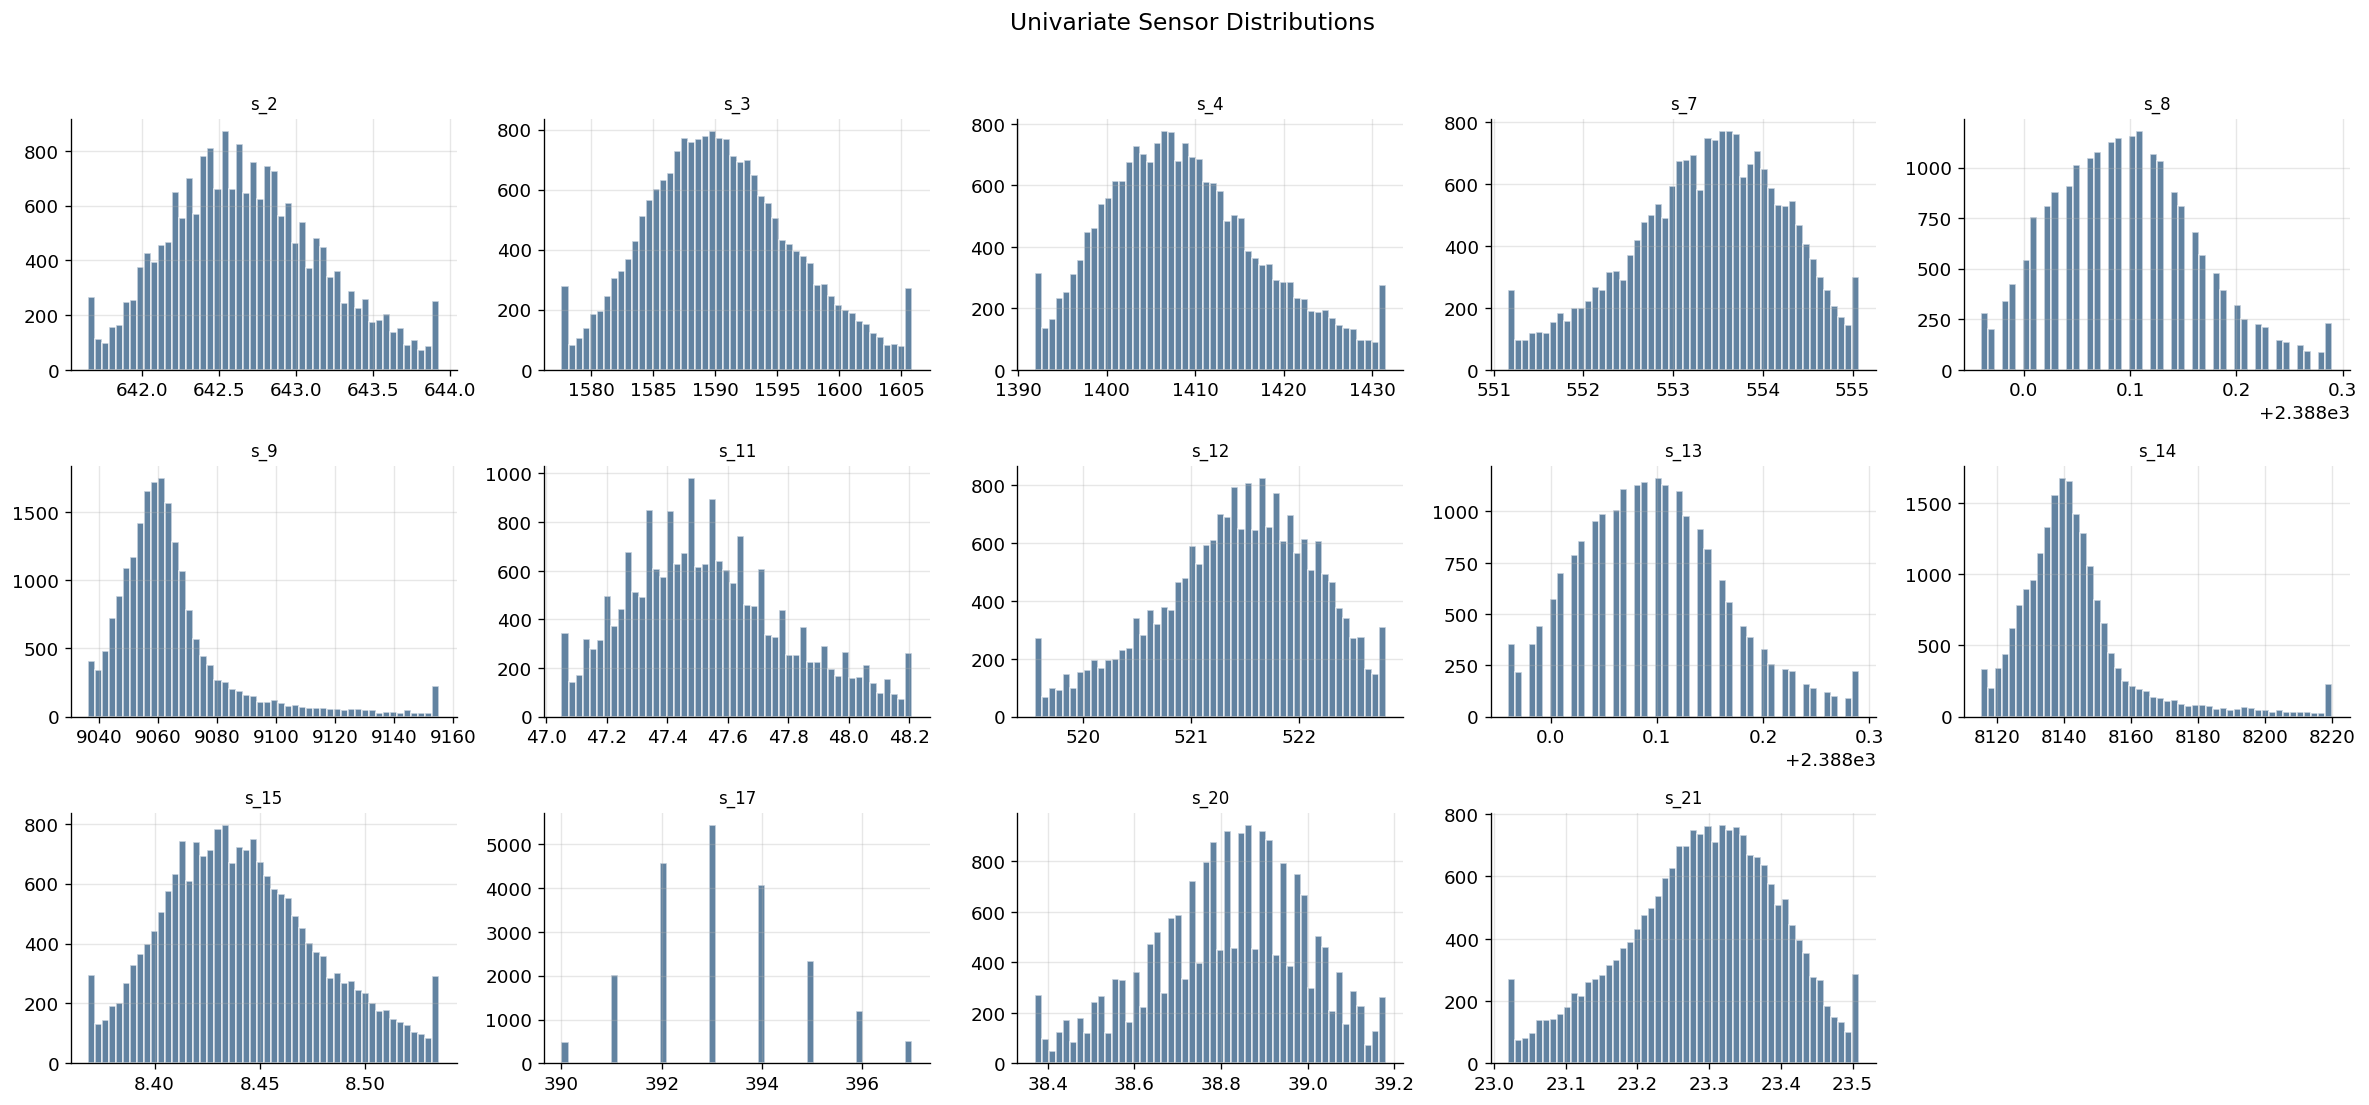

,semantic,mean,std,skewness,kurtosis,min,max
sensor,,,,,,,
s_2,LPC outlet temperature (°R),642.680751,0.493480,0.303619,-0.322196,641.6500,643.93000
s_3,HPC outlet temperature (°R),1590.519824,6.037949,0.291379,-0.255355,1577.6130,1605.87100
s_4,LPT outlet temperature (°R),1408.927477,8.906258,0.425643,-0.318712,1391.8830,1431.51700
s_7,HPC outlet pressure (psia),553.368224,0.874390,-0.376859,-0.341465,551.1600,555.07000
s_8,Physical fan speed (rpm),2388.096533,0.069961,0.413197,-0.097446,2387.9600,2388.29000
s_9,Physical core speed (rpm),9065.036693,20.812184,2.110614,5.487449,9036.3500,9155.23900
s_11,HPC outlet static pressure (psia),47.540997,0.264366,0.451989,-0.320389,47.0500,48.21000
s_12,Ratio of fuel flow to Ps30 (pps/psia),521.414000,0.729302,-0.422973,-0.313164,519.5500,522.80000
s_13,Corrected fan speed (rpm),2388.096042,0.070674,0.396454,-0.120502,2387.9600,2388.29000


In [4]:
# Sensor semantics dictionary (from Source A — Carl Kirstein)
SENSOR_SEMANTICS = {
    's_1': 'Fan inlet temperature (°R)',
    's_2': 'LPC outlet temperature (°R)',
    's_3': 'HPC outlet temperature (°R)',
    's_4': 'LPT outlet temperature (°R)',
    's_5': 'Fan inlet pressure (psia)',
    's_6': 'Bypass-duct pressure (psia)',
    's_7': 'HPC outlet pressure (psia)',
    's_8': 'Physical fan speed (rpm)',
    's_9': 'Physical core speed (rpm)',
    's_10': 'Engine pressure ratio (P50/P2)',
    's_11': 'HPC outlet static pressure (psia)',
    's_12': 'Ratio of fuel flow to Ps30 (pps/psia)',
    's_13': 'Corrected fan speed (rpm)',
    's_14': 'Corrected core speed (rpm)',
    's_15': 'Bypass ratio',
    's_16': 'Burner fuel-air ratio',
    's_17': 'Bleed enthalpy',
    's_18': 'Required fan speed',
    's_19': 'Required fan conversion speed',
    's_20': 'High-pressure turbines cool air flow',
    's_21': 'Low-pressure turbines cool air flow',
}
# Filter to remaining sensors only
Sensor_dictionary = {k: v for k, v in SENSOR_SEMANTICS.items() if k in SENSOR_COLS}

# Univariate profiling: distribution histograms + summary stats
import math
n_sensors = len(sensor_cols)
n_cols_grid = 5
n_rows_grid = math.ceil(n_sensors / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(4*n_cols_grid, 3*n_rows_grid))
axes = axes.flatten()

profile_data = []
for i, sensor in enumerate(sensor_cols):
    ax = axes[i]
    ax.hist(df_train[sensor], bins=50, color=COLORS[0], alpha=0.7, edgecolor='white')
    ax.set_title(sensor, fontsize=10)
    
    skew = df_train[sensor].skew()
    kurt = df_train[sensor].kurtosis()
    profile_data.append({
        'sensor': sensor,
        'semantic': Sensor_dictionary.get(sensor, ''),
        'mean': df_train[sensor].mean(),
        'std': df_train[sensor].std(),
        'skewness': skew,
        'kurtosis': kurt,
        'min': df_train[sensor].min(),
        'max': df_train[sensor].max(),
    })

for j in range(n_sensors, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Univariate Sensor Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

profile_df = pd.DataFrame(profile_data).set_index('sensor')
display(profile_df)

**Turbofan Component Reference**:
A low pressure compressor **(LPC)** and high pressure compressor **(HPC)** supply compressed high temperature, high pressure gases to the combustor. Low pressure turbine **(LPT)** can decelerate and pressurize air to improve the chemical energy conversion efficiency of aviation kerosene. High pressure turbines **(HPT)** generate mechanical energy by using high temperature and high pressure gas strike turbine blades. **Low-pressure rotor (N1), high-pressure rotor (N2), and nozzle** guarantee the combustion efficiency of the engine.

### 3.3 Sensor Degradation Trends vs RUL
Plot sensor readings against RUL (reversed x-axis: healthy on left → failure on right). Look for monotonic trends as evidence of degradation signal.

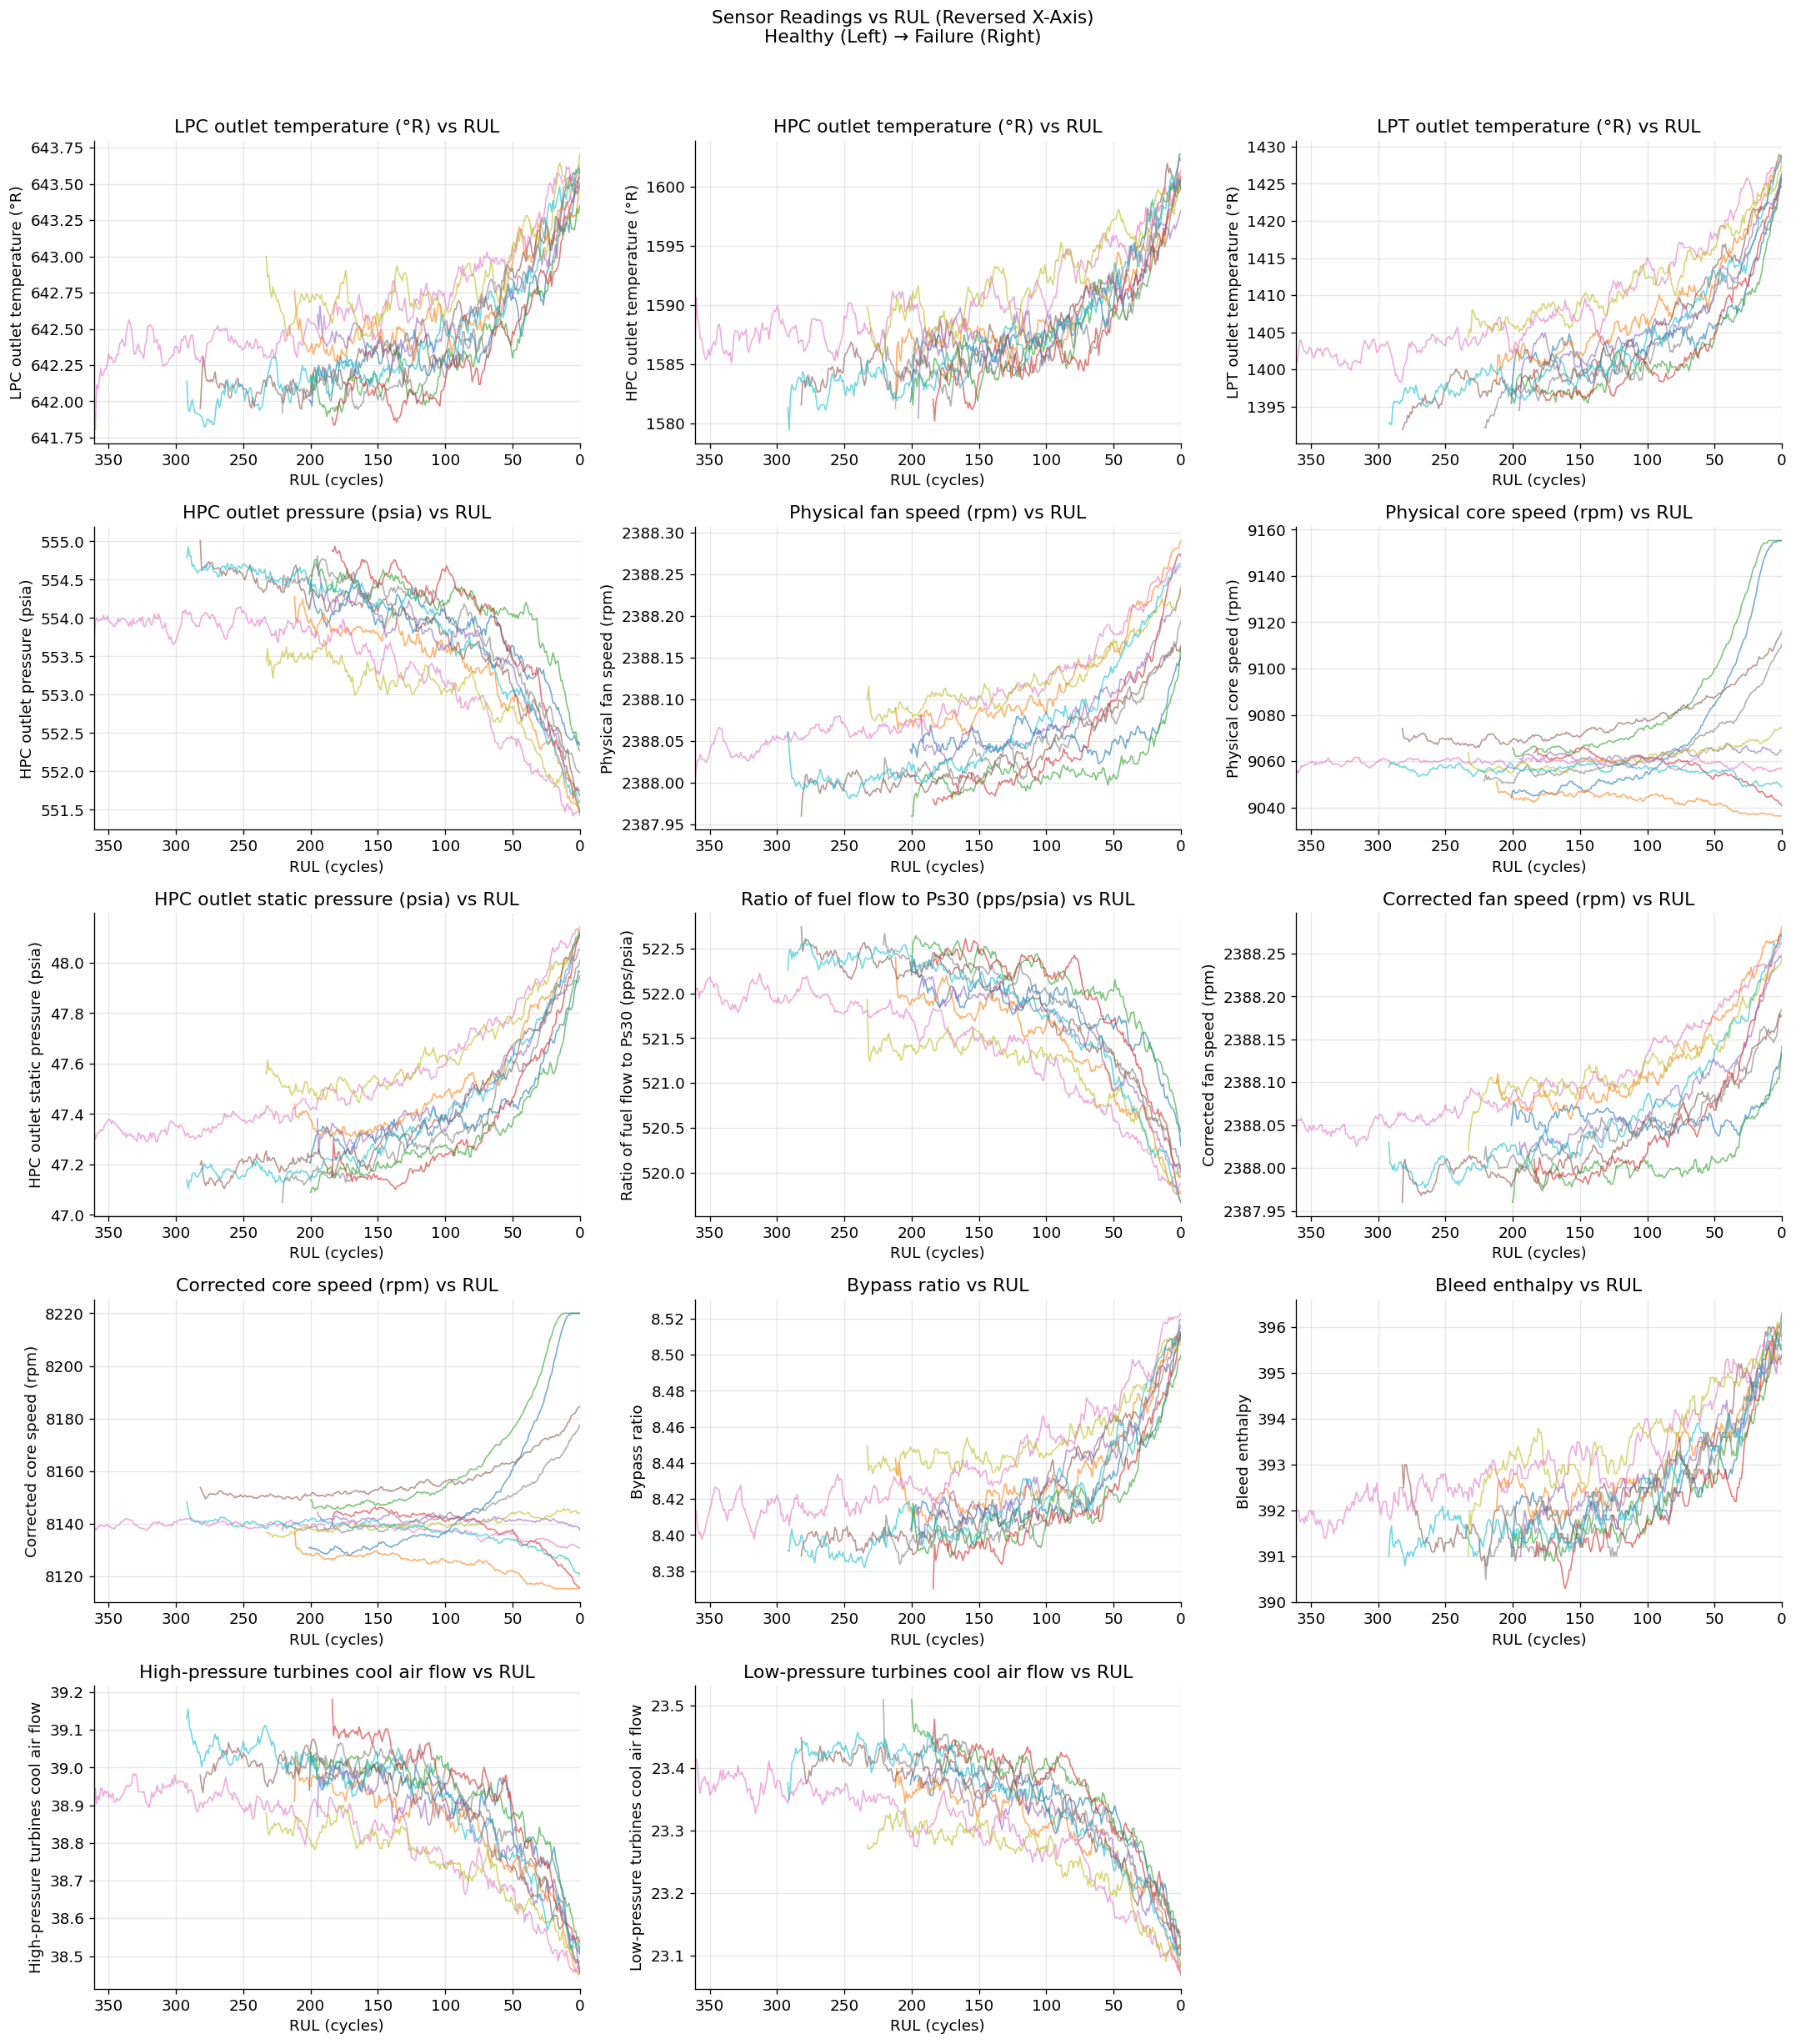

In [5]:
import matplotlib.pyplot as plt
import math
import numpy as np

def sensor_trends_analysis(df, sensor_cols, sensor_dict=None, n_engines=10, random_state=None):
    df_eda = df.copy()
    max_rul = df_eda['RUL'].max()
    
    n_sensors = len(sensor_cols)
    n_cols = 3
    n_rows = math.ceil(n_sensors / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    
    # Select random engines
    rng = np.random.default_rng(seed=random_state)
    engines = rng.choice(df_eda['unit_number'].unique(), size=n_engines, replace=False)
    
    for i, sensor in enumerate(sensor_cols):
        ax = axes[i]
        for unit in engines:
            subset = df_eda[df_eda['unit_number'] == unit].sort_values('time_cycles')
            smoothed = subset[sensor].rolling(window=10, min_periods=1).mean()
            ax.plot(subset['RUL'].values, smoothed.values, alpha=0.6, linewidth=1)
        
        ax.set_xlim(max_rul, 0)  # Reverse X-axis
        ax.set_xlabel('RUL (cycles)')
        y_label = sensor_dict.get(sensor, sensor) if sensor_dict else sensor
        ax.set_ylabel(y_label)
        ax.set_title(f'{y_label} vs RUL')
    
    # Remove empty subplots
    for j in range(n_sensors, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle('Sensor Readings vs RUL (Reversed X-Axis)\nHealthy (Left) → Failure (Right)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


# Usage example (plots random 10 engines, reproducible):
sensor_trends_analysis(df_train, sensor_cols, Sensor_dictionary, n_engines=10, random_state=42)

### Graph Analysis: Sensor Trends vs RUL

- The reversed x-axis highlights degradation progression clearly: curves are generally flatter at high RUL and become steeper near low RUL, indicating accelerated behavior close to failure.
- Clear upward trends (sensor value rises as failure approaches): `s_2` (LPC outlet temperature), `s_3` (HPC outlet temperature), `s_4` (LPT outlet temperature), `s_8` (Physical fan speed), `s_11` (HPC outlet static pressure), `s_13` (Corrected fan speed), `s_15` (Bypass ratio), and `s_17` (Bleed enthalpy).
- Clear downward trends (sensor value falls as failure approaches): `s_7` (HPC outlet pressure), `s_12` (Ratio of fuel flow to Ps30), `s_20` (High-pressure turbines cool air flow), and `s_21` (Low-pressure turbines cool air flow).
- `s_9` (Physical core speed) and `s_14` (Corrected core speed) show high between-engine dispersion with sharper late-stage shifts, suggesting high-variance but potentially high-signal behavior.
- Most sensors show non-linear trajectories over RUL (slow early changes, faster late changes), so linear-only assumptions are likely insufficient.

#### Feature Engineering Implications
1. Include trend-aware descriptors (rolling mean, local slope, curvature) to capture late-stage acceleration.
2. Add first-difference (`diff`) features to quantify rate of change per cycle.
3. Add EWMA features (span 5, 10) for responsive late-stage trend detection.
4. Add lag features (1, 2, 5 steps) for short-term history at each timestep.
5. Keep `s_9` and `s_14` despite high variance — their late-stage bursts carry prognostic signal.
6. Use models capable of non-linear mapping (gradient-boosted trees, neural networks).

### 3.4 Statistical Trend Validation (Spearman Correlation)
Validate observed trends with statistical tests. Spearman rank correlation quantifies monotonic association between each sensor and RUL with significance testing.

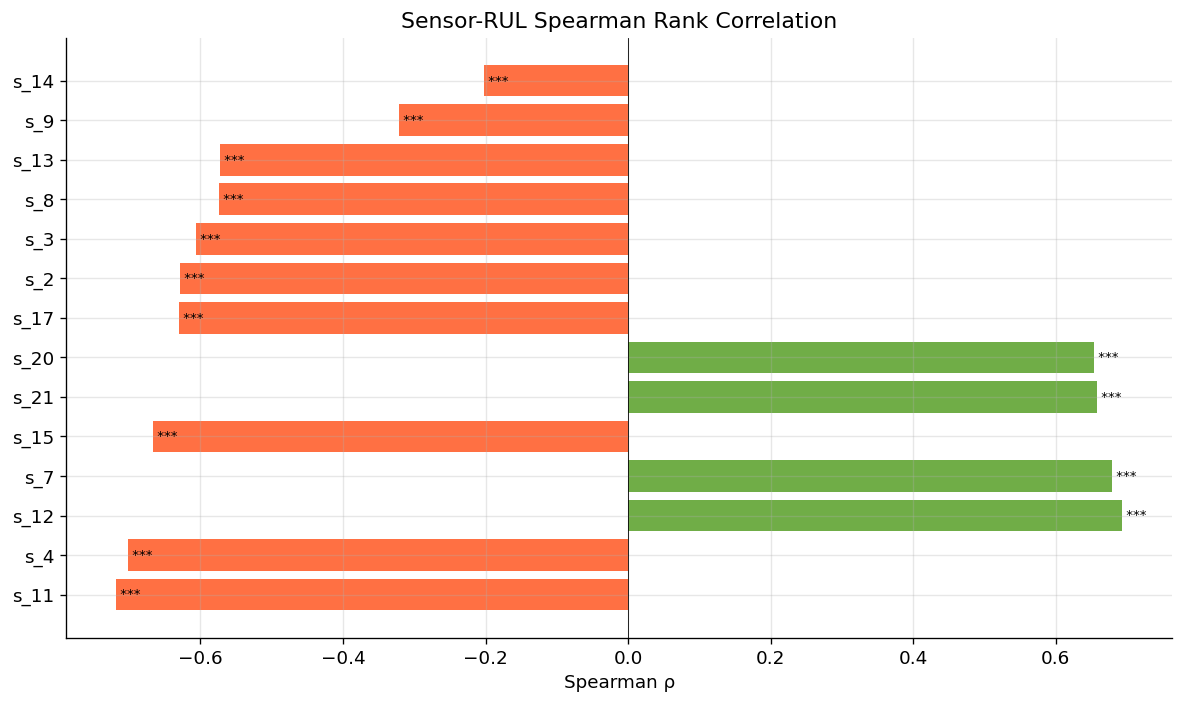

=== Spearman Correlation Summary (*** = p < 0.001) ===


,semantic,spearman_rho,p_value,significant
sensor,,,,
s_11,HPC outlet static pressure (psia),-0.718128,0.000000e+00,True
s_4,LPT outlet temperature (°R),-0.701769,0.000000e+00,True
s_12,Ratio of fuel flow to Ps30 (pps/psia),0.693142,0.000000e+00,True
s_7,HPC outlet pressure (psia),0.678837,0.000000e+00,True
s_15,Bypass ratio,-0.665902,0.000000e+00,True
s_21,Low-pressure turbines cool air flow,0.657413,0.000000e+00,True
s_20,High-pressure turbines cool air flow,0.653329,0.000000e+00,True
s_17,Bleed enthalpy,-0.629387,0.000000e+00,True
s_2,LPC outlet temperature (°R),-0.628579,0.000000e+00,True


In [6]:
# Spearman rank correlation with significance test
spearman_results = []
for sensor in sensor_cols:
    rho, pval = stats.spearmanr(df_train[sensor], df_train['RUL'])
    spearman_results.append({
        'sensor': sensor,
        'semantic': Sensor_dictionary.get(sensor, ''),
        'spearman_rho': rho,
        'p_value': pval,
        'significant': pval < 0.001,
        'abs_rho': abs(rho),
        'direction': 'positive' if rho > 0 else 'negative',
    })

spearman_df = pd.DataFrame(spearman_results).sort_values('abs_rho', ascending=False)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = [COLORS[2] if r > 0 else COLORS[3] for r in spearman_df['spearman_rho']]
bars = ax.barh(spearman_df['sensor'], spearman_df['spearman_rho'], color=colors)
ax.set_xlabel('Spearman ρ')
ax.set_title('Sensor-RUL Spearman Rank Correlation')
ax.axvline(0, color='black', linewidth=0.5)

# Annotate significance
for bar, sig in zip(bars, spearman_df['significant']):
    if sig:
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, ' ***', 
                va='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()

print("=== Spearman Correlation Summary (*** = p < 0.001) ===")
display(spearman_df[['sensor', 'semantic', 'spearman_rho', 'p_value', 'significant']].set_index('sensor'))

### Statistical Validation Summary

- All remaining sensors show **statistically significant** monotonic association with RUL (p < 0.001).
- **Strongest negative Spearman ρ** (value increases toward failure): `s_11`, `s_4`, `s_2`, `s_3`, `s_13`, `s_15`, `s_8`, `s_17`.
- **Strongest positive Spearman ρ** (value decreases toward failure): `s_12`, `s_7`, `s_21`, `s_20`.
- `s_9` and `s_14` show high variance but still statistically significant monotonic trends.
- **Key finding**: every visual trend from section 3.3 is confirmed by the statistical test — no visual conclusions are unsupported.

#### Recommended Sensor Priority for Feature Engineering
| Priority | Sensors | Rationale |
|----------|---------|-----------|
| **High** | s_11, s_4, s_12, s_7, s_2, s_3, s_21, s_20 | Strong monotonic RUL association (|ρ| > 0.5) |
| **Medium** | s_13, s_15, s_8, s_17 | Moderate association with clear trends |
| **Keep (high variance)** | s_9, s_14 | Significant but high dispersion — useful for non-linear models |

### 3.5 Correlation Heatmap & Redundancy Analysis
Check for multicollinearity and shared degradation modes between sensors.

### 3.3 Diagnostic: Correlation Analysis
Check for multicollinearity. If two sensors are highly correlated, they carry redundant information.

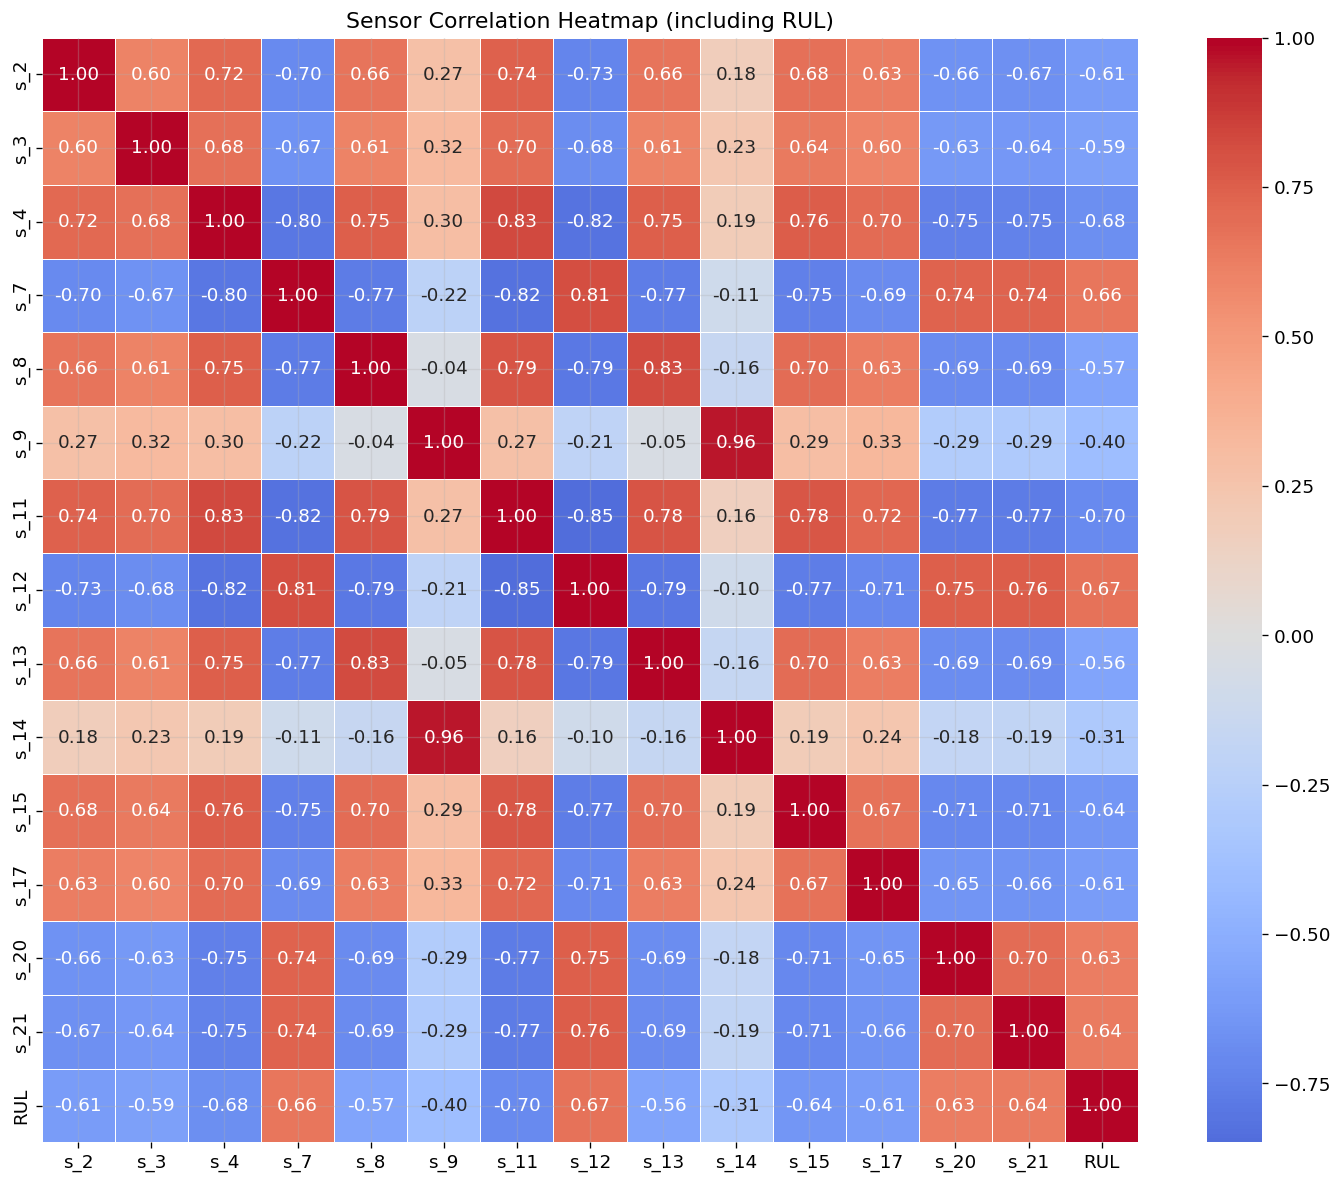

=== Highly Correlated Sensor Pairs (|r| > 0.9) ===
  s_14 ↔ s_9: r = 0.959

=== Sensor-RUL Pearson Correlation ===
s_11   -0.697527
s_4    -0.680406
s_15   -0.644359
s_2    -0.607851
s_17   -0.607292
s_3    -0.585889
s_8    -0.565334
s_13   -0.564392
s_9    -0.398568
s_14   -0.311738
s_20    0.631037
s_21    0.637153
s_7     0.658647
s_12    0.673323
Name: RUL, dtype: float64


In [7]:
# Correlation heatmap including RUL
corr = df_train[sensor_cols + ['RUL']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Sensor Correlation Heatmap (including RUL)')
plt.tight_layout()
plt.show()

# Identify highly correlated sensor pairs (|r| > 0.9)
print("=== Highly Correlated Sensor Pairs (|r| > 0.9) ===")
corr_sensors = corr.drop('RUL', axis=0).drop('RUL', axis=1)
upper = corr_sensors.where(np.triu(np.ones(corr_sensors.shape), k=1).astype(bool))
high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns for row in upper.index 
             if abs(upper.loc[row, col]) > 0.9]
for s1, s2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f"  {s1} ↔ {s2}: r = {r:.3f}")

# RUL correlation ranking
rul_corr = corr['RUL'].drop('RUL').sort_values()
print("\n=== Sensor-RUL Pearson Correlation ===")
print(rul_corr)

### Graph Analysis: Correlation Heatmap

- The selected sensors form strong correlated blocks, indicating shared degradation modes and non-trivial redundancy.
- Strongest pairwise sensor relationship: `s_9` ↔ `s_14` at approximately **0.96**, suggesting near-duplicate information for some patterns.
- `RUL` has strongest negative associations with `s_11` (**-0.70**) and `s_4` (**-0.68**), meaning these sensors increase as failure approaches (RUL decreases).
- `RUL` has strongest positive associations with `s_12` (**+0.67**), `s_7` (**+0.66**), `s_21` (**+0.64**), and `s_20` (**+0.63**), meaning these tend to decrease toward failure.
- Mid-strength links (`|corr| ~ 0.56–0.64`) across several sensors show that signal is distributed, not concentrated in one feature.
- Modeling implication: feature selection should preserve both positively and negatively correlated groups to avoid directional bias.
- Regularization or dimensionality reduction is justified to reduce multicollinearity-driven instability in linear or tree-based baselines.

#### Suggested Actions
1. **Keep both `s_9` and `s_14` for now** — despite 0.96 correlation, their high-variance late-stage behavior may still contribute unique signal in non-linear models. Let model-based feature importance arbitrate.
2. **Build a PCA-based health index** from the full sensor space — the strong correlated block structure means PC1 will be a powerful composite degradation indicator.
3. **Include sensors from both correlation directions** (positive and negative with RUL) — top candidates: `s_11`, `s_4`, `s_12`, `s_7`, `s_21`, `s_20`, `s_2`, `s_3`.
4. **Apply PCA dimensionality reduction** as an optional dataset variant — given the redundancy, 5 PCs (~87% variance) can replace 14 raw sensors for compact model pipelines.
5. **Use regularization** (L1/L2) or tree-based ensembles rather than raw OLS to handle collinearity in flat-feature models.

### 3.6 PCA Variance Diagnostic
The strong correlated block structure suggests that PCA can effectively compress the sensor space. We use PCA as a diagnostic to quantify how much information can be preserved with fewer components.

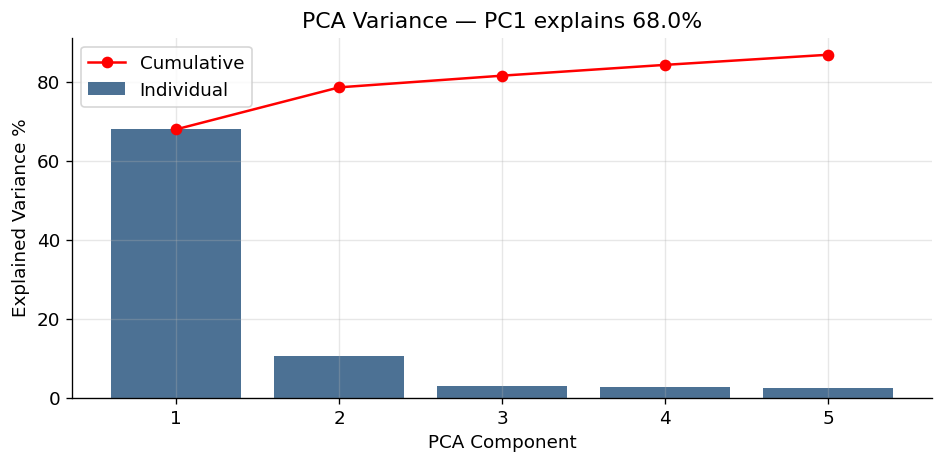

In [8]:
def pca_analysis(df, sensor_cols):
    """Perform PCA to assess global variance."""
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df[sensor_cols])
    
    pca = PCA(n_components=5)
    pca.fit(X_scaled)
    
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(1, 6), explained_variance * 100, color=COLORS[0], alpha=0.8, label='Individual')
    plt.plot(range(1, 6), cumulative_variance * 100, 'r-o', label='Cumulative')
    plt.xlabel('PCA Component')
    plt.ylabel('Explained Variance %')
    plt.title(f'PCA Variance — PC1 explains {explained_variance[0]*100:.1f}%')
    plt.legend()
    plt.tight_layout()
    plt.show()

pca_analysis(df_train, sensor_cols)

### Graph Analysis: PCA Explained Variance

- **PC1 explains 69.6%** of total variance, indicating one dominant latent degradation direction shared by many sensors.
- Cumulative variance rises to roughly **78%** with 2 components and about **87%** with 5 components.
- The large PC1-to-PC2 drop shows diminishing returns after the first component; later PCs add finer, secondary behavior.
- This aligns with the correlation heatmap: sensors move in coordinated blocks, so much structure is compressible.
- Practical takeaway for baselines: low-dimensional representations (e.g., 3–5 PCs) can retain most global information with lower noise sensitivity.
- Practical takeaway for deep sequence models: raw sensors remain useful, but PCA features can be added as auxiliary channels for stabilization and faster convergence.

#### Suggested Actions
1. **Create a "PCA-compact" dataset variant** retaining 95% variance (~7-8 components) — suitable for linear models, SVR, and lightweight tree baselines.
2. **Add PC1 as a `health_index` feature** to the full-sensor datasets — it acts as a single-number degradation summary and is strongly predictive on its own.
3. **Do NOT apply PCA to deep learning datasets** — LSTMs/Transformers learn their own internal representations; PCA pre-compression removes potentially useful fine-grained sensor interactions.
4. **Fit PCA on training data only** and transform validation with the same projection to prevent leakage.
5. **Consider PCA on engineered features** (after rolling/lag/diff creation) as a second reduction stage for very high-dimensional experiment variants (300+ features).

## 3.7 AI4I Health State Detection (Step 6)

Add AI4I change-point detection via tool wear and compare warning lead-time against C-MAPSS FD001.

In [1]:
# ── CELL: AI4I Change-Point Detection via Tool Wear ──────────────────────────
# For AI4I, impairment onset is detected when CUSUM identifies shifts in
# normalized sensor/tool-wear behavior.

import sys
import os
sys.path.append(os.path.abspath('..'))

from src.changepoint import cusum_detector, detect_health_transitions
from src.data_loader import load_all_datasets, FEATURE_COLS, SENSOR_COLS
from src.preprocessor import full_preprocess_pipeline
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ai4i = pd.read_csv('../data/raw/ai4i2020.csv')

AI4I_SENSOR_COLS = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
 ]

def construct_ai4i_rul(df: pd.DataFrame,
                       wear_col: str = 'Tool wear [min]',
                       max_rul: int = 125) -> pd.DataFrame:
    df = df.copy().reset_index(drop=True)
    run_id = 0
    cycle_id = 1
    run_ids, cycle_ids = [], []

    for i in range(len(df)):
        if i > 0 and df[wear_col].iloc[i] < df[wear_col].iloc[i - 1]:
            run_id += 1
            cycle_id = 1
        run_ids.append(run_id)
        cycle_ids.append(cycle_id)
        cycle_id += 1

    df['unit_id'] = run_ids
    df['cycle'] = cycle_ids

    max_wear = df.groupby('unit_id')[wear_col].max().rename('max_wear')
    df = df.merge(max_wear, on='unit_id')
    df['RUL'] = (df['max_wear'] - df[wear_col]).clip(upper=max_rul)
    return df.drop(columns=['max_wear'])

ai4i_with_rul = construct_ai4i_rul(ai4i)

# Normalise AI4I sensors for CUSUM
scaler_ai4i = MinMaxScaler()
ai4i_with_rul[AI4I_SENSOR_COLS] = scaler_ai4i.fit_transform(ai4i_with_rul[AI4I_SENSOR_COLS])

THRESHOLD = 4.0  # slightly lower than C-MAPSS; AI4I degrades faster
transitions_ai4i = detect_health_transitions(
    ai4i_with_rul, AI4I_SENSOR_COLS, threshold=THRESHOLD
)

print('AI4I fleet health transitions detected:')
print(transitions_ai4i.describe().round(1))

AI4I fleet health transitions detected:
       unit_id  health_transition_cycle  max_cycle  rul_at_transition
count    120.0                    120.0      120.0              120.0
mean      59.5                      6.2       83.3               77.1
std       34.8                      3.5        8.3                9.2
min        0.0                      3.0       11.0                8.0
25%       29.8                      5.0       81.0               74.8
50%       59.5                      5.5       84.0               78.0
75%       89.2                      6.0       88.0               82.0
max      119.0                     20.0      101.0               96.0


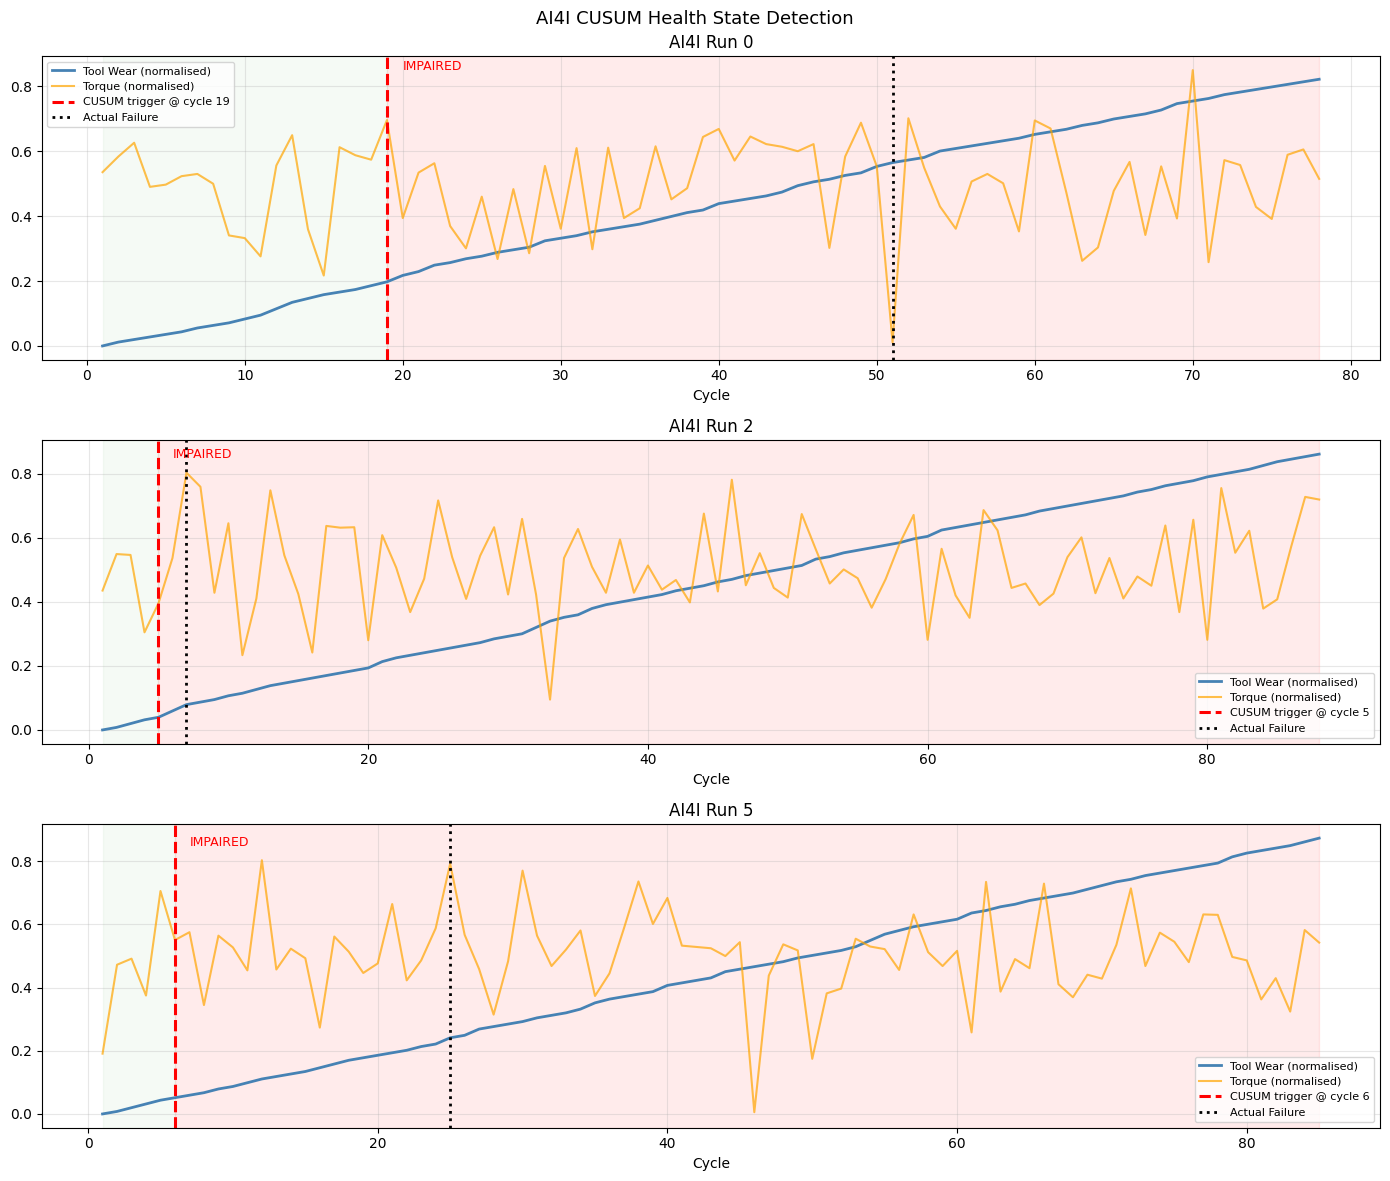

In [2]:
# ── CELL: Plot AI4I Health Transition for Sample Runs ────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
sample_runs = [0, 2, 5]

for ax, run_id in zip(axes, sample_runs):
    run_data = ai4i_with_rul[ai4i_with_rul['unit_id'] == run_id].sort_values('cycle')

    cp_idx = cusum_detector(run_data['Tool wear [min]'].values, threshold=THRESHOLD)
    cp_cycle = run_data['cycle'].iloc[cp_idx] if cp_idx is not None else None

    ax.plot(run_data['cycle'], run_data['Tool wear [min]'],
            color='steelblue', linewidth=2, label='Tool Wear (normalised)')
    ax.plot(run_data['cycle'], run_data['Torque [Nm]'],
            color='orange', linewidth=1.5, alpha=0.7, label='Torque (normalised)')

    if cp_cycle is not None:
        ax.axvline(cp_cycle, color='red', linestyle='--', linewidth=2.2,
                   label=f'CUSUM trigger @ cycle {cp_cycle}')
        ax.axvspan(cp_cycle, run_data['cycle'].max(), alpha=0.08, color='red')
        ax.text(cp_cycle + 1, 0.85, 'IMPAIRED', color='red', fontsize=9)

    failures = run_data[run_data['Machine failure'] == 1]
    if len(failures) > 0:
        ax.axvline(failures['cycle'].min(), color='black', linestyle=':',
                   linewidth=2, label='Actual Failure')

    ax.axvspan(run_data['cycle'].min(),
               cp_cycle if cp_cycle is not None else run_data['cycle'].max(),
               alpha=0.04, color='green')
    ax.set_title(f'AI4I Run {run_id}')
    ax.set_xlabel('Cycle')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('AI4I CUSUM Health State Detection', fontsize=13)
plt.tight_layout()
plt.show()

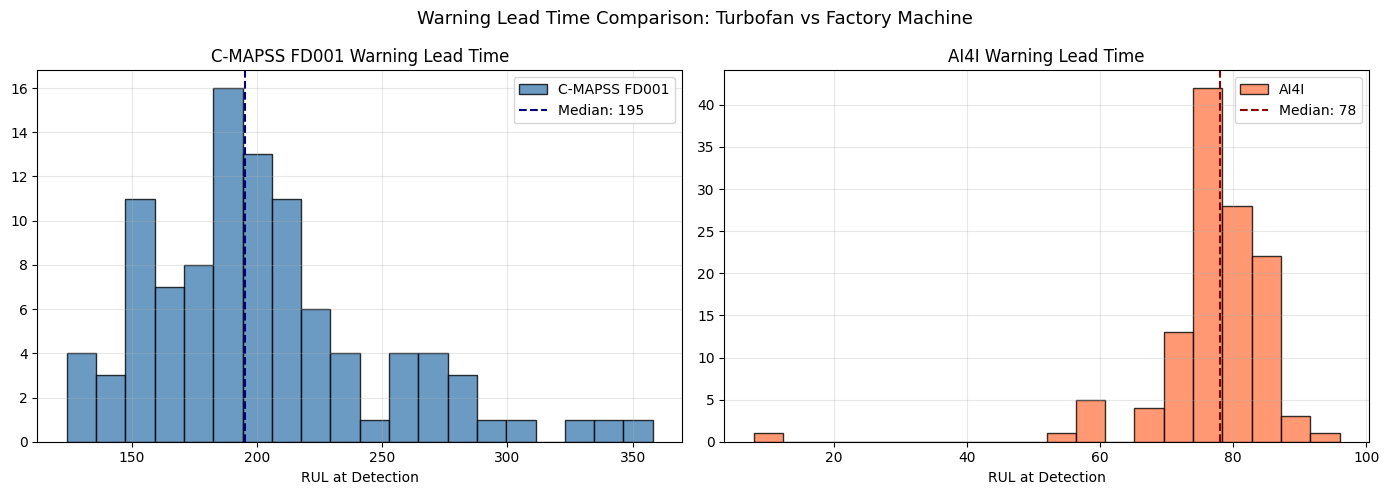

In [3]:
# ── CELL: Compare C-MAPSS vs AI4I Warning Lead Time ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# C-MAPSS FD001 warning lead time
datasets_nb3 = load_all_datasets(data_dir='../data/raw')
df_tr, _, _ = full_preprocess_pipeline(
    df_train=datasets_nb3['FD001']['train'],
    df_test=datasets_nb3['FD001']['test'],
    feature_cols=FEATURE_COLS,
    sensor_cols=SENSOR_COLS,
    smooth=True,
    max_rul=125
)
trans_fd001 = detect_health_transitions(df_tr, SENSOR_COLS, threshold=5.0)

axes[0].hist(trans_fd001['rul_at_transition'], bins=20, color='steelblue',
             edgecolor='black', alpha=0.8, label='C-MAPSS FD001')
axes[0].axvline(trans_fd001['rul_at_transition'].median(), color='navy',
                linestyle='--', label=f"Median: {trans_fd001['rul_at_transition'].median():.0f}")
axes[0].set_title('C-MAPSS FD001 Warning Lead Time')
axes[0].set_xlabel('RUL at Detection')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(transitions_ai4i['rul_at_transition'], bins=20, color='coral',
             edgecolor='black', alpha=0.8, label='AI4I')
axes[1].axvline(transitions_ai4i['rul_at_transition'].median(), color='darkred',
                linestyle='--', label=f"Median: {transitions_ai4i['rul_at_transition'].median():.0f}")
axes[1].set_title('AI4I Warning Lead Time')
axes[1].set_xlabel('RUL at Detection')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Warning Lead Time Comparison: Turbofan vs Factory Machine', fontsize=13)
plt.tight_layout()
plt.show()